# **Vision Transformer**

### **Libraries**

In [1]:
from transformers import ViTImageProcessor, ViTForImageClassification
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sklearn.svm import SVC
import tensorflow as tf
from PIL import Image
import pandas as pd
import numpy as np
import itertools
import cv2 as cv
import torch
import os

2025-11-30 09:38:57.823592: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764495538.001447      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764495538.054858      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

### **Configuration**

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
dataset_path = "/kaggle/input/ucmerced-landuse-dataset/UCMerced_LandUse"

categories = [
    d for d in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, d))
]
images = []
labels = []

In [4]:
for i, category in enumerate(categories):
    category_path = os.path.join(dataset_path, category)
    print(category_path)
    for image_name in os.listdir(category_path):
        image_path = os.path.join(category_path, image_name)
        img = cv.imread(image_path)
        if img is not None:
            images.append(img)
            labels.append(i)

/kaggle/input/ucmerced-landuse-dataset/UCMerced_LandUse/airplane
/kaggle/input/ucmerced-landuse-dataset/UCMerced_LandUse/tenniscourt
/kaggle/input/ucmerced-landuse-dataset/UCMerced_LandUse/river
/kaggle/input/ucmerced-landuse-dataset/UCMerced_LandUse/denseresidential
/kaggle/input/ucmerced-landuse-dataset/UCMerced_LandUse/parkinglot
/kaggle/input/ucmerced-landuse-dataset/UCMerced_LandUse/storagetanks
/kaggle/input/ucmerced-landuse-dataset/UCMerced_LandUse/overpass
/kaggle/input/ucmerced-landuse-dataset/UCMerced_LandUse/sparseresidential
/kaggle/input/ucmerced-landuse-dataset/UCMerced_LandUse/mediumresidential
/kaggle/input/ucmerced-landuse-dataset/UCMerced_LandUse/intersection
/kaggle/input/ucmerced-landuse-dataset/UCMerced_LandUse/baseballdiamond
/kaggle/input/ucmerced-landuse-dataset/UCMerced_LandUse/runway
/kaggle/input/ucmerced-landuse-dataset/UCMerced_LandUse/chaparral
/kaggle/input/ucmerced-landuse-dataset/UCMerced_LandUse/freeway
/kaggle/input/ucmerced-landuse-dataset/UCMerced_L

In [5]:
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42, stratify=labels)

In [6]:
processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

In [7]:
model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')
model = model.to(device)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [8]:
model.classifier = torch.nn.Identity() # classification head removed

In [9]:
model.eval()

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [10]:
def extract_vit_features(image):
    image = Image.fromarray(cv.cvtColor(image, cv.COLOR_BGR2RGB))
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)  # hidden states
    features = outputs.hidden_states[-1]  # last hidden state
    features = features.squeeze(0).mean(dim=0)
    features = features
    return features.cpu().numpy()

In [11]:
X_train_vit_features = np.array([
    extract_vit_features(img)
    for img in tqdm(X_train, desc="Extracting ViT features Train")
])

Extracting ViT features Train:   0%|          | 0/1680 [00:00<?, ?it/s]

In [12]:
X_test_vit_features = np.array([
    extract_vit_features(img) for img in tqdm(X_test, desc="Extracting ViT features Test")
])

Extracting ViT features Test:   0%|          | 0/420 [00:00<?, ?it/s]

### **Classifier Training (SVM - ViT)**

In [13]:
svm_vit = SVC(kernel='linear', C=1.0)
svm_vit.fit(X_train_vit_features, y_train)

SVC(kernel='linear')

### **Predicition**

In [14]:
y_pred_vit = svm_vit.predict(X_test_vit_features)

### **Evaluation**

In [15]:
accuracy_vit = accuracy_score(y_test, y_pred_vit)
accuracy_vit

0.9714285714285714

In [16]:
conf_matrix_vit = confusion_matrix(y_test, y_pred_vit)
print("ViT Confusion Matrix:")
print(conf_matrix_vit)

ViT Confusion Matrix:
[[19  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0]
 [ 0 18  0  0  0  0  0  1  0  1  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 19  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0]
 [ 0  0  0 17  1  0  0  1  1  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 19  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 19  0  0  0  0  0  0  1  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  1  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  1  0  0 19  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  

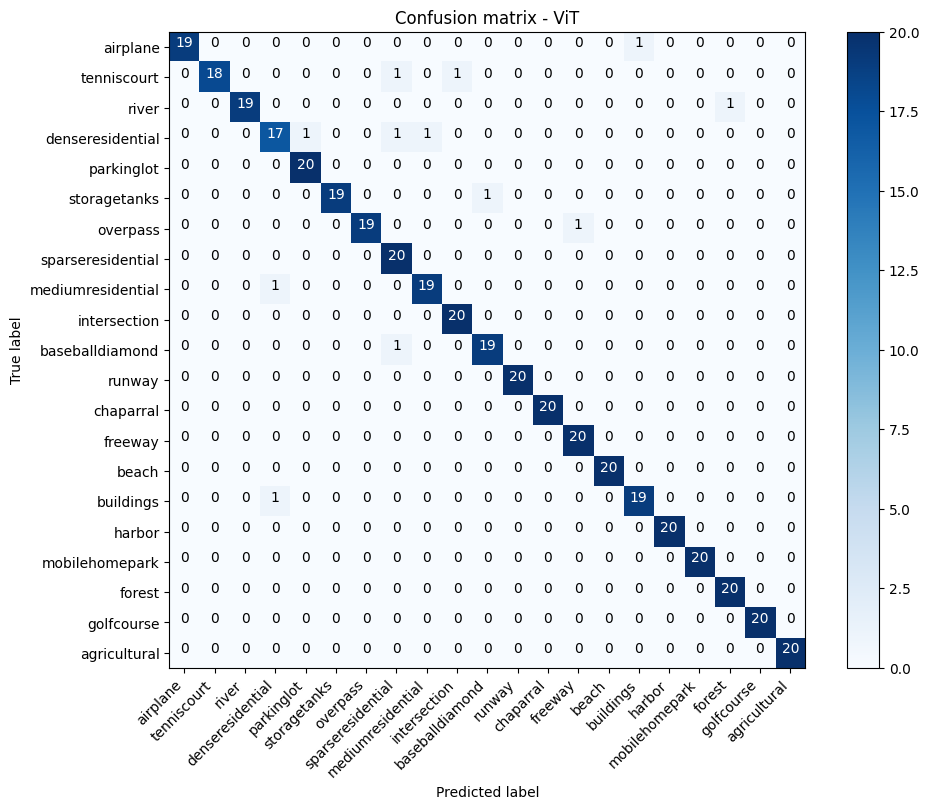

In [17]:
plt.figure(figsize=(10, 8))
plt.imshow(conf_matrix_vit, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion matrix - ViT")
plt.colorbar()
tick_marks = np.arange(len(categories))
plt.xticks(tick_marks, categories, rotation=45, ha='right')
plt.yticks(tick_marks, categories)
plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')

thresh = conf_matrix_vit.max() / 2.
for i, j in itertools.product(range(conf_matrix_vit.shape[0]), range(conf_matrix_vit.shape[1])):
    plt.text(j, i, format(conf_matrix_vit[i, j], 'd'),
            horizontalalignment="center",
            color="white" if conf_matrix_vit[i, j] > thresh else "black")
plt.show()